In [1]:
# UWB LOS/NLOS Classification
# Dataset has CIR0-CIR1015 as separate columns!

"""
Quick Setup:
conda create -n uwb python=3.10 -y
conda activate uwb
pip install pandas numpy matplotlib seaborn scikit-learn xgboost jupyter scipy
"""


'\nQuick Setup:\nconda create -n uwb python=3.10 -y\nconda activate uwb\npip install pandas numpy matplotlib seaborn scikit-learn xgboost jupyter scipy\n'

# IMPORTS


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_curve, auc,
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
)
import xgboost as xgb
from scipy.stats import skew, kurtosis

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("=" * 70)
print("UWB LOS/NLOS CLASSIFICATION")
print("Dataset with CIR0-CIR1015 columns")
print("=" * 70)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)


UWB LOS/NLOS CLASSIFICATION
Dataset with CIR0-CIR1015 columns


In [3]:
# PATHS


In [4]:
BASE_DIR = Path(".")
DATASET_DIR = BASE_DIR / "Dataset" / "UWB-LOS-NLOS-Data-Set" / "dataset"
RESULTS_DIR = BASE_DIR / "results"
MODELS_DIR = RESULTS_DIR / "models"
FIGURES_DIR = RESULTS_DIR / "figures"

RESULTS_DIR.mkdir(exist_ok=True)
MODELS_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(exist_ok=True)

print(f"\nDataset: {DATASET_DIR.absolute()}")



Dataset: C:\Users\angcl\OneDrive - Singapore Institute Of Technology\Y2\Tri2\Data Analytics\Project\Dataset\UWB-LOS-NLOS-Data-Set\dataset


In [5]:
# LOAD DATA


In [6]:
print("\n" + "=" * 70)
print("LOADING DATASET")
print("=" * 70)

all_files = list(DATASET_DIR.glob("*.csv"))
print(f"Found {len(all_files)} CSV files")

dataframes = []
for i, file in enumerate(all_files):
    print(f"  Loading {i+1}/{len(all_files)}: {file.name}...", end='\r')
    df_temp = pd.read_csv(file)
    df_temp['environment'] = file.stem
    dataframes.append(df_temp)

df_raw = pd.concat(dataframes, ignore_index=True)
print(f"\nLoaded {len(df_raw):,} samples")
print(f"  Columns: {df_raw.shape[1]}")



LOADING DATASET
Found 7 CSV files
  Loading 7/7: uwb_dataset_part7.csv...
Loaded 42,000 samples
  Columns: 1032


In [7]:
# IDENTIFY COLUMNS


In [8]:
print("\n" + "=" * 70)
print("ANALYZING DATASET STRUCTURE")
print("=" * 70)

# Find CIR columns (CIR0, CIR1, ..., CIR1015)
cir_columns = [col for col in df_raw.columns if col.startswith('CIR') and col[3:].isdigit()]
cir_columns_sorted = sorted(cir_columns, key=lambda x: int(x[3:]))

# Other feature columns
other_features = [col for col in df_raw.columns 
                  if col not in cir_columns 
                  and col not in ['NLOS', 'environment']]

print(f"\nDataset Structure:")
print(f"  CIR columns: {len(cir_columns_sorted)} (CIR0 to CIR1015)")
print(f"  Other features: {len(other_features)}")
print(f"    {other_features}")
print(f"  Target: NLOS (0=LOS, 1=NLOS)")



ANALYZING DATASET STRUCTURE

Dataset Structure:
  CIR columns: 1016 (CIR0 to CIR1015)
  Other features: 14
    ['RANGE', 'FP_IDX', 'FP_AMP1', 'FP_AMP2', 'FP_AMP3', 'STDEV_NOISE', 'CIR_PWR', 'MAX_NOISE', 'RXPACC', 'CH', 'FRAME_LEN', 'PREAM_LEN', 'BITRATE', 'PRFR']
  Target: NLOS (0=LOS, 1=NLOS)


In [9]:
# BASIC EDA


In [10]:
print("\n" + "=" * 70)
print("EXPLORATORY DATA ANALYSIS")
print("=" * 70)

# Class distribution
print("\n1. Class Distribution:")
class_counts = df_raw['NLOS'].value_counts().sort_index()
print(f"   LOS (0): {class_counts.get(0, 0):,}")
print(f"   NLOS (1): {class_counts.get(1, 0):,}")

# Environment distribution
print("\n2. Samples per Environment:")
for env, count in df_raw['environment'].value_counts().items():
    print(f"   {env}: {count:,}")

# CIR statistics
print("\n3. CIR Columns:")
sample_cir = df_raw[cir_columns_sorted].iloc[0].values
print(f"   Length: {len(sample_cir)} values")
print(f"   Range: [{sample_cir.min():.1f}, {sample_cir.max():.1f}]")
print(f"   Mean: {sample_cir.mean():.1f}")



EXPLORATORY DATA ANALYSIS

1. Class Distribution:
   LOS (0): 21,000
   NLOS (1): 21,000

2. Samples per Environment:
   uwb_dataset_part1: 6,000
   uwb_dataset_part2: 6,000
   uwb_dataset_part3: 6,000
   uwb_dataset_part4: 6,000
   uwb_dataset_part5: 6,000
   uwb_dataset_part6: 6,000
   uwb_dataset_part7: 6,000

3. CIR Columns:
   Length: 1016 values
   Range: [0.0, 23077.0]
   Mean: 395.2


In [11]:
# VISUALIZATIONS



CREATING VISUALIZATIONS
Saved: results\figures\01_eda.png


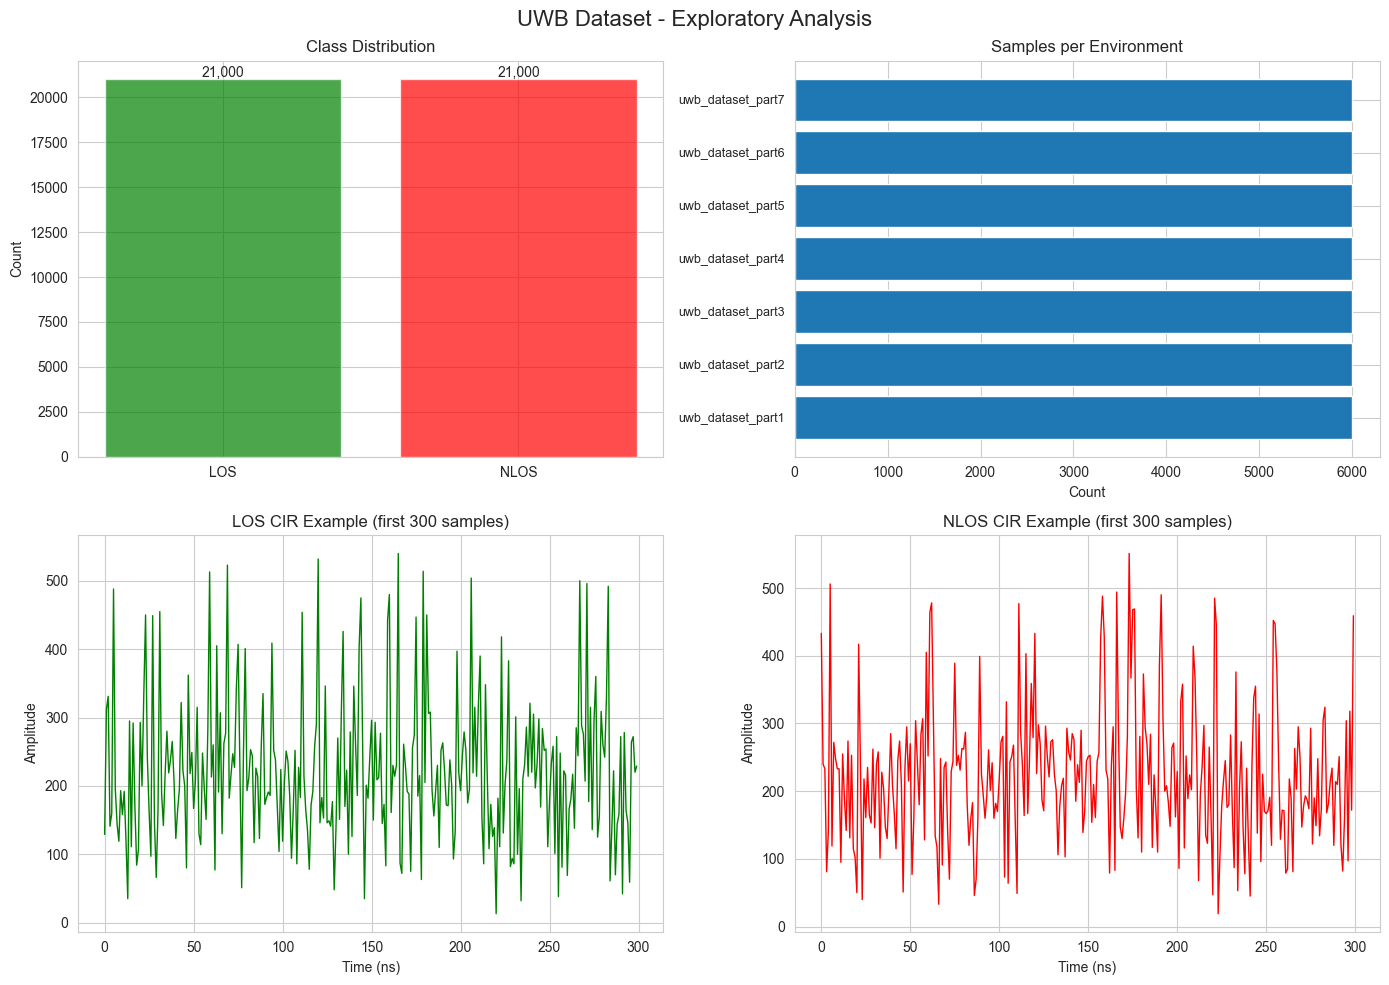

In [12]:
print("\n" + "=" * 70)
print("CREATING VISUALIZATIONS")
print("=" * 70)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('UWB Dataset - Exploratory Analysis', fontsize=16)

# 1. Class distribution
axes[0, 0].bar(['LOS', 'NLOS'], class_counts.values, color=['green', 'red'], alpha=0.7)
axes[0, 0].set_title('Class Distribution')
axes[0, 0].set_ylabel('Count')
for i, v in enumerate(class_counts.values):
    axes[0, 0].text(i, v, f'{v:,}', ha='center', va='bottom')

# 2. Environment distribution
env_counts = df_raw['environment'].value_counts()
axes[0, 1].barh(range(len(env_counts)), env_counts.values)
axes[0, 1].set_yticks(range(len(env_counts)))
axes[0, 1].set_yticklabels(env_counts.index, fontsize=9)
axes[0, 1].set_title('Samples per Environment')
axes[0, 1].set_xlabel('Count')

# 3. LOS CIR example
los_sample = df_raw[df_raw['NLOS'] == 0][cir_columns_sorted].iloc[0].values
axes[1, 0].plot(los_sample[:300], color='green', linewidth=1)
axes[1, 0].set_title('LOS CIR Example (first 300 samples)')
axes[1, 0].set_xlabel('Time (ns)')
axes[1, 0].set_ylabel('Amplitude')

# 4. NLOS CIR example
nlos_sample = df_raw[df_raw['NLOS'] == 1][cir_columns_sorted].iloc[0].values
axes[1, 1].plot(nlos_sample[:300], color='red', linewidth=1)
axes[1, 1].set_title('NLOS CIR Example (first 300 samples)')
axes[1, 1].set_xlabel('Time (ns)')
axes[1, 1].set_ylabel('Amplitude')

plt.tight_layout()
plt.savefig(FIGURES_DIR / '01_eda.png', dpi=300, bbox_inches='tight')
print(f"Saved: {FIGURES_DIR / '01_eda.png'}")
plt.show()


In [13]:
# FEATURE ENGINEERING (OPTIONAL - Extract stats from CIR)


In [14]:
print("\n" + "=" * 70)
print("FEATURE ENGINEERING")
print("=" * 70)

print("You have two options:")
print("Extract statistics (faster training)")

def extract_cir_stats(row):
    """Extract statistics from CIR columns (with type conversion)"""
    # CRITICAL: Convert strings to numbers!
    cir = pd.to_numeric(row[cir_columns_sorted].values, errors='coerce')
    cir = cir[~np.isnan(cir)].astype(float)  # Remove NaN and force float
    
    if len(cir) == 0:
        return pd.Series({
            'cir_mean': 0, 'cir_std': 0, 'cir_max': 0, 'cir_min': 0,
            'cir_peak_to_avg': 0, 'cir_energy': 0, 'cir_rms': 0,
            'cir_skewness': 0, 'cir_kurtosis': 0,
            'cir_peak_idx': 0, 'cir_num_peaks': 0, 'cir_centroid': 0
        })
    
    return pd.Series({
        'cir_mean': float(np.mean(cir)),
        'cir_std': float(np.std(cir)),
        'cir_max': float(np.max(cir)),
        'cir_min': float(np.min(cir)),
        'cir_peak_to_avg': float(np.max(cir) / (np.mean(cir) + 1e-10)),
        'cir_energy': float(np.sum(cir ** 2)),
        'cir_rms': float(np.sqrt(np.mean(cir ** 2))),
        'cir_skewness': float(skew(cir)),
        'cir_kurtosis': float(kurtosis(cir)),
        'cir_peak_idx': int(np.argmax(cir)),
        'cir_num_peaks': int(np.sum(cir > 0.5 * np.max(cir))),
        'cir_centroid': float(np.sum(np.arange(len(cir)) * cir) / (np.sum(cir) + 1e-10))
    })

print("Extracting CIR statistics (1-2 minutes)...")
import time
start = time.time()

cir_stats_list = []
for idx in range(len(df_raw)):
    if idx % 5000 == 0:
        print(f"  {idx:,}/{len(df_raw):,} ({100*idx/len(df_raw):.0f}%)", end='\r')
    cir_stats_list.append(extract_cir_stats(df_raw.iloc[idx]))

cir_stats = pd.DataFrame(cir_stats_list)
print(f"\nDone in {time.time()-start:.0f} seconds!")

feature_columns = other_features + list(cir_stats.columns)
df_features = pd.concat([df_raw[other_features], cir_stats], axis=1)

print(f"\nTotal features: {len(feature_columns)}")


FEATURE ENGINEERING
You have two options:
Extract statistics (faster training)
Extracting CIR statistics (1-2 minutes)...
  40,000/42,000 (95%)
Done in 76 seconds!

Total features: 26


In [15]:
# PREPROCESSING


In [16]:
print("\n" + "=" * 70)
print("DATA PREPROCESSING")
print("=" * 70)

X = df_features.copy()
y = df_raw['NLOS'].copy()

print(f"Features: {X.shape}")
print(f"Target: {y.shape}")

# Handle missing/infinite values
print("\n1. Handling missing values...")
X = X.replace([np.inf, -np.inf], np.nan)
missing_count = X.isnull().sum().sum()
if missing_count > 0:
    print(f"   Filling {missing_count} missing values")
    X = X.fillna(X.median())
else:
    print(f"   No missing values ")

# Split data
print("\n2. Splitting data (80/20)...")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y
)
print(f"   Train: {X_train.shape[0]:,} samples")
print(f"   Test:  {X_test.shape[0]:,} samples")

# Scale features
print("\n3. Scaling features...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print(f"   Scaled with StandardScaler")



DATA PREPROCESSING
Features: (42000, 26)
Target: (42000,)

1. Handling missing values...
   No missing values 

2. Splitting data (80/20)...
   Train: 33,600 samples
   Test:  8,400 samples

3. Scaling features...
   Scaled with StandardScaler


In [17]:
# FEATURE IMPORTANCE



FEATURE IMPORTANCE

Top 15 Most Important Features:
        feature  importance
         RXPACC    0.203382
        cir_max    0.106417
          RANGE    0.103727
cir_peak_to_avg    0.072830
   cir_centroid    0.062871
        CIR_PWR    0.061899
      MAX_NOISE    0.053599
        FP_AMP3    0.052677
        cir_std    0.049596
        FP_AMP2    0.034536
        FP_AMP1    0.026149
       cir_mean    0.025743
    STDEV_NOISE    0.025185
   cir_skewness    0.022998
        cir_rms    0.020872

 Saved: results\figures\02_feature_importance.png


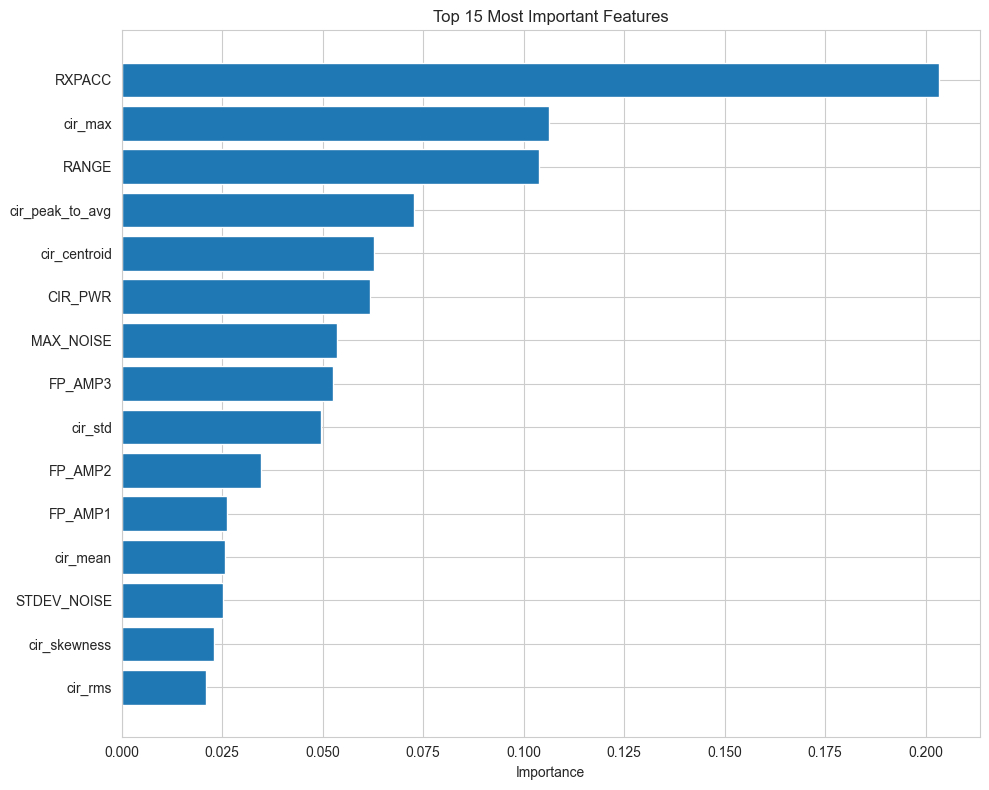

In [18]:
print("\n" + "=" * 70)
print("FEATURE IMPORTANCE")
print("=" * 70)

rf_temp = RandomForestClassifier(n_estimators=50, random_state=RANDOM_SEED, n_jobs=-1)
rf_temp.fit(X_train_scaled, y_train)

importances = pd.DataFrame({
    'feature': X_train_scaled.columns,
    'importance': rf_temp.feature_importances_
}).sort_values('importance', ascending=False)

print(f"\nTop 15 Most Important Features:")
print(importances.head(15).to_string(index=False))

# Visualize
plt.figure(figsize=(10, 8))
top_n = 15
plt.barh(range(top_n), importances.head(top_n)['importance'].values[::-1])
plt.yticks(range(top_n), importances.head(top_n)['feature'].values[::-1])
plt.xlabel('Importance')
plt.title(f'Top {top_n} Most Important Features')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '02_feature_importance.png', dpi=300, bbox_inches='tight')
print(f"\n Saved: {FIGURES_DIR / '02_feature_importance.png'}")
plt.show()

importances.to_csv(RESULTS_DIR / 'feature_importance.csv', index=False)


In [19]:
# MODEL 1: LOGISTIC REGRESSION


In [20]:
print("\n" + "=" * 70)
print("MODEL 1: LOGISTIC REGRESSION (BASELINE)")
print("=" * 70)

lr_model = LogisticRegression(max_iter=1000, random_state=RANDOM_SEED)
lr_model.fit(X_train_scaled, y_train)

y_pred_lr = lr_model.predict(X_test_scaled)
y_pred_proba_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

print(f"\nAccuracy:  {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lr):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_lr):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_lr):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_pred_proba_lr):.4f}")



MODEL 1: LOGISTIC REGRESSION (BASELINE)

Accuracy:  0.8636
Precision: 0.8995
Recall:    0.8186
F1-Score:  0.8571
ROC-AUC:   0.9228


In [21]:
# MODEL 2: RANDOM FOREST


In [22]:
print("\n" + "=" * 70)
print("MODEL 2: RANDOM FOREST")
print("=" * 70)

rf_model = RandomForestClassifier(
    n_estimators=200, max_depth=20, min_samples_split=5,
    random_state=RANDOM_SEED, n_jobs=-1
)
rf_model.fit(X_train_scaled, y_train)

y_pred_rf = rf_model.predict(X_test_scaled)
y_pred_proba_rf = rf_model.predict_proba(X_test_scaled)[:, 1]

print(f"\nAccuracy:  {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_rf):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_pred_proba_rf):.4f}")



MODEL 2: RANDOM FOREST

Accuracy:  0.9188
Precision: 0.9358
Recall:    0.8993
F1-Score:  0.9172
ROC-AUC:   0.9736


In [23]:
# MODEL 3: XGBOOST (BEST)


In [24]:
print("\n" + "=" * 70)
print("MODEL 3: XGBOOST (BEST MODEL)")
print("=" * 70)

xgb_model = xgb.XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    random_state=RANDOM_SEED, n_jobs=-1
)
xgb_model.fit(X_train_scaled, y_train)

y_pred_xgb = xgb_model.predict(X_test_scaled)
y_pred_proba_xgb = xgb_model.predict_proba(X_test_scaled)[:, 1]

print(f"\nAccuracy:  {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_xgb):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_xgb):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_xgb):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_pred_proba_xgb):.4f}")

print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred_xgb, target_names=['LOS', 'NLOS']))

# Save model
xgb_model.save_model(str(MODELS_DIR / 'xgboost_model.json'))
print(f"\n Saved model")



MODEL 3: XGBOOST (BEST MODEL)

Accuracy:  0.9208
Precision: 0.9355
Recall:    0.9040
F1-Score:  0.9195
ROC-AUC:   0.9787

Detailed Classification Report:
              precision    recall  f1-score   support

         LOS       0.91      0.94      0.92      4200
        NLOS       0.94      0.90      0.92      4200

    accuracy                           0.92      8400
   macro avg       0.92      0.92      0.92      8400
weighted avg       0.92      0.92      0.92      8400


 Saved model


In [25]:
# MODEL COMPARISON



MODEL COMPARISON

Model Performance:
              Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC
Logistic Regression  0.863571   0.899529 0.818571  0.857143 0.922774
      Random Forest  0.918810   0.935828 0.899286  0.917193 0.973579
            XGBoost  0.920833   0.935452 0.904048  0.919482 0.978720

 Saved: results\figures\03_model_comparison.png


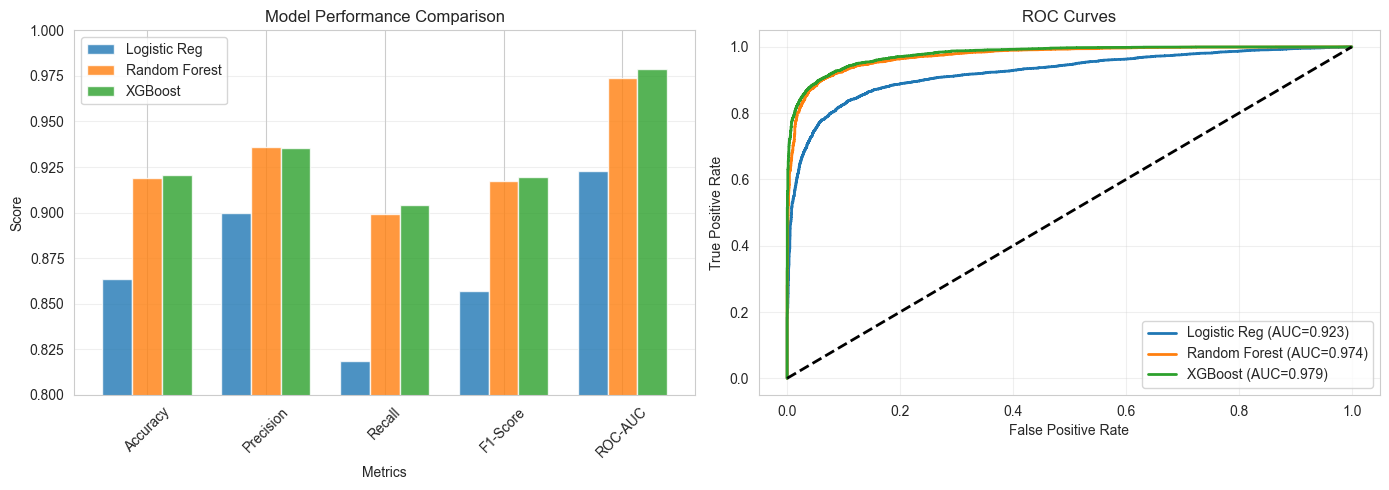

In [26]:
print("\n" + "=" * 70)
print("MODEL COMPARISON")
print("=" * 70)

comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb)
    ],
    'Precision': [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_xgb)
    ],
    'Recall': [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_xgb)
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_xgb)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, y_pred_proba_lr),
        roc_auc_score(y_test, y_pred_proba_rf),
        roc_auc_score(y_test, y_pred_proba_xgb)
    ]
})

print("\nModel Performance:")
print(comparison.to_string(index=False))
comparison.to_csv(RESULTS_DIR / 'model_comparison.csv', index=False)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
x = np.arange(len(metrics))
width = 0.25

axes[0].bar(x - width, comparison.iloc[0, 1:].values, width, label='Logistic Reg', alpha=0.8)
axes[0].bar(x, comparison.iloc[1, 1:].values, width, label='Random Forest', alpha=0.8)
axes[0].bar(x + width, comparison.iloc[2, 1:].values, width, label='XGBoost', alpha=0.8)
axes[0].set_xlabel('Metrics')
axes[0].set_ylabel('Score')
axes[0].set_title('Model Performance Comparison')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics, rotation=45)
axes[0].legend()
axes[0].set_ylim([0.80, 1.0])
axes[0].grid(alpha=0.3, axis='y')

# ROC curves
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_pred_proba_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_proba_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_pred_proba_xgb)

axes[1].plot(fpr_lr, tpr_lr, label=f'Logistic Reg (AUC={auc(fpr_lr, tpr_lr):.3f})', lw=2)
axes[1].plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC={auc(fpr_rf, tpr_rf):.3f})', lw=2)
axes[1].plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC={auc(fpr_xgb, tpr_xgb):.3f})', lw=2)
axes[1].plot([0, 1], [0, 1], 'k--', lw=2)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curves')
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / '03_model_comparison.png', dpi=300, bbox_inches='tight')
print(f"\n Saved: {FIGURES_DIR / '03_model_comparison.png'}")
plt.show()


In [27]:
# XGBOOST DETAILED RESULTS



XGBOOST - DETAILED ANALYSIS

Confusion Matrix:
              Predicted
            LOS    NLOS
Actual LOS   3938    262
       NLOS   403   3797

 Saved: results\figures\04_xgboost_detailed.png


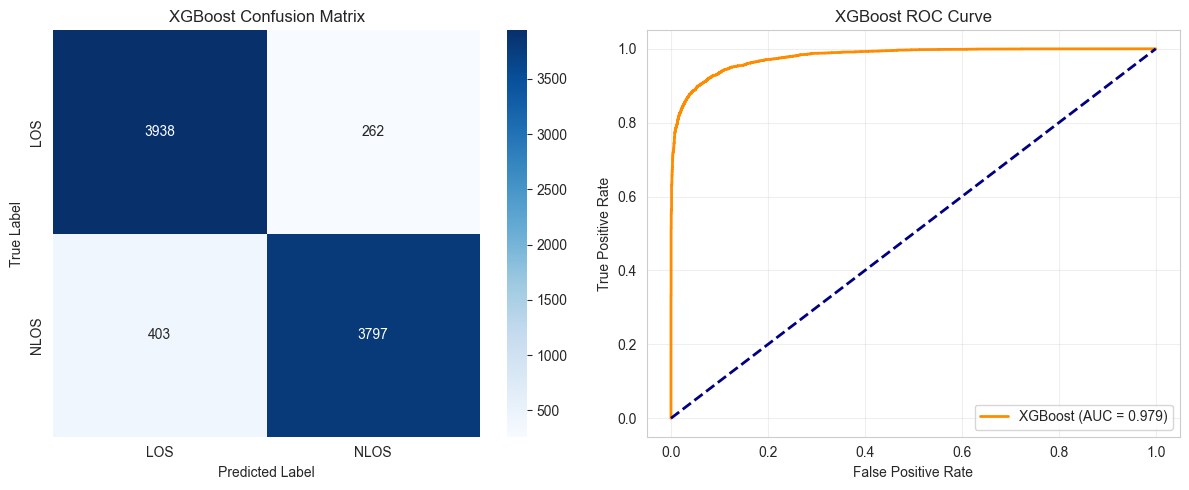

In [28]:
print("\n" + "=" * 70)
print("XGBOOST - DETAILED ANALYSIS")
print("=" * 70)

cm = confusion_matrix(y_test, y_pred_xgb)

print("\nConfusion Matrix:")
print(f"              Predicted")
print(f"            LOS    NLOS")
print(f"Actual LOS  {cm[0,0]:5d}  {cm[0,1]:5d}")
print(f"       NLOS {cm[1,0]:5d}  {cm[1,1]:5d}")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['LOS', 'NLOS'], yticklabels=['LOS', 'NLOS'])
axes[0].set_title('XGBoost Confusion Matrix')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

axes[1].plot(fpr_xgb, tpr_xgb, color='darkorange', lw=2,
            label=f'XGBoost (AUC = {auc(fpr_xgb, tpr_xgb):.3f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('XGBoost ROC Curve')
axes[1].legend(loc="lower right")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / '04_xgboost_detailed.png', dpi=300, bbox_inches='tight')
print(f"\n Saved: {FIGURES_DIR / '04_xgboost_detailed.png'}")
plt.show()


In [29]:
# SUMMARY


In [30]:
print("\n" + "=" * 70)
print("PROJECT SUMMARY")
print("=" * 70)

summary = f"""
DATASET:
  Total Samples: {len(df_raw):,}
  LOS: {class_counts.get(0, 0):,}
  NLOS: {class_counts.get(1, 0):,}
  Features: {len(feature_columns)}

DATA SPLIT:
  Train: {len(X_train):,} (80%)
  Test: {len(X_test):,} (20%)

BEST MODEL (XGBoost):
  Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}
  F1-Score: {f1_score(y_test, y_pred_xgb):.4f}
  ROC-AUC: {roc_auc_score(y_test, y_pred_proba_xgb):.4f}

FILES SAVED:
  - {len(list(FIGURES_DIR.glob('*.png')))} figures
  - {len(list(MODELS_DIR.glob('*')))} models
  - {len(list(RESULTS_DIR.glob('*.csv')))} CSV files

Location: {RESULTS_DIR.absolute()}
"""

print(summary)

with open(RESULTS_DIR / 'summary.txt', 'w') as f:
    f.write(summary)

print("\n" + "=" * 70)
print(" ANALYSIS COMPLETE!")
print("=" * 70)
print(f"\nResults saved to: {RESULTS_DIR.absolute()}")



PROJECT SUMMARY

DATASET:
  Total Samples: 42,000
  LOS: 21,000
  NLOS: 21,000
  Features: 26

DATA SPLIT:
  Train: 33,600 (80%)
  Test: 8,400 (20%)

BEST MODEL (XGBoost):
  Accuracy: 0.9208
  F1-Score: 0.9195
  ROC-AUC: 0.9787

FILES SAVED:
  - 4 figures
  - 1 models
  - 2 CSV files

Location: C:\Users\angcl\OneDrive - Singapore Institute Of Technology\Y2\Tri2\Data Analytics\Project\results


 ANALYSIS COMPLETE!

Results saved to: C:\Users\angcl\OneDrive - Singapore Institute Of Technology\Y2\Tri2\Data Analytics\Project\results
